# Analyse du dataset Teen Mental Health

## Contexte
Les réseaux sociaux occupent une place importante dans la vie des adolescents. Leur utilisation excessive peut avoir un impact sur plusieurs dimensions du bien-être, notamment le sommeil, le stress et la santé mentale.

## Problématique
Dans quelle mesure l’usage des réseaux sociaux est-il associé au niveau de stress et au bien-être des adolescents ?

## Objectif
L’objectif de cette analyse est d’explorer les principales variables du dataset afin d’identifier les facteurs les plus liés au stress, au sommeil et à l’usage des réseaux sociaux, puis de préparer les indicateurs utiles pour un dashboard interactif.


## 1. Chargement des données

Dans cette première étape, on importe les bibliothèques nécessaires et on charge le dataset afin de commencer l’exploration.


### Première lecture des données

L’affichage des premières lignes permet d’identifier la structure générale du dataset, les colonnes disponibles et le type d’informations contenues dans chaque observation.


# Analyse par Syrine — Stress & Sommeil


# Analyse par Chahd — Stress & Sommeil

In [13]:
import pandas as pd
df = pd.read_csv("../data/Teen_Mental_Health_Dataset.csv")
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


### Structure du dataset

Cette étape permet de vérifier :
- le nombre de lignes et de colonnes,
- les types de variables,
- la présence éventuelle de valeurs manquantes.

Cela aide à distinguer les variables numériques des variables catégorielles avant l’analyse.
### Statistiques descriptives

Les statistiques descriptives donnent une première vision des variables numériques, notamment :
- la moyenne,
- l’écart-type,
- les valeurs minimales et maximales,
- la répartition générale des données.

Elles permettent déjà de repérer d’éventuelles anomalies ou valeurs extrêmes.
## 2. Vérification de la qualité des données

L’analyse des valeurs manquantes est importante pour s’assurer que les résultats obtenus seront fiables. Si certaines colonnes contiennent des données manquantes, il faudra en tenir compte dans l’interprétation ou dans le nettoyage des données.


Observation : le dataset semble exploitable directement si le nombre de valeurs manquantes reste faible ou nul.



In [14]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 140.4 KB


age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

## 3. Analyse univariée

Cette partie vise à étudier les variables une par une afin de comprendre leur distribution dans la population étudiée.
### Interprétation

Ce graphique montre la distribution de l’âge dans l’échantillon. Il permet de vérifier si les adolescents étudiés sont répartis de manière homogène ou si certaines tranches d’âge sont plus représentées que d’autres.


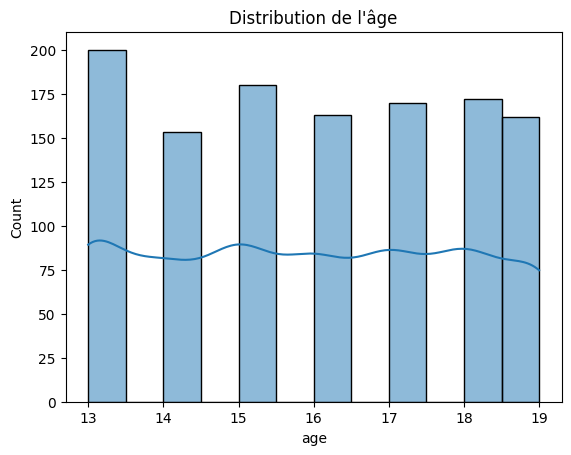

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["age"], kde=True)
plt.title("Distribution de l'âge")
plt.show()

### Interprétation

Cette visualisation montre combien de temps les adolescents passent quotidiennement sur les réseaux sociaux. Elle permet d’identifier si l’usage est globalement modéré ou élevé dans l’échantillon.


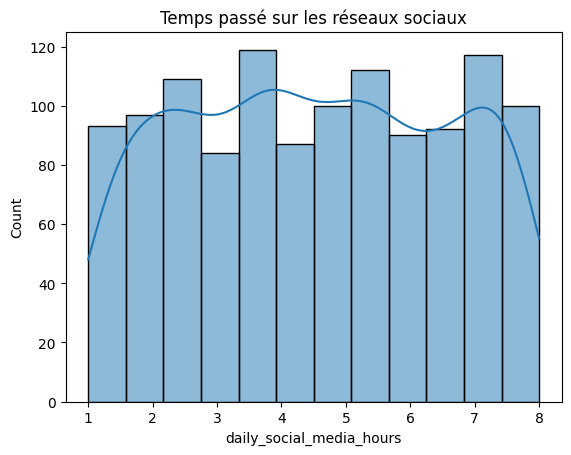

In [16]:
sns.histplot(df["daily_social_media_hours"], kde=True)
plt.title("Temps passé sur les réseaux sociaux")
plt.show()

### Interprétation

Ce graphique présente la répartition du niveau de stress dans la population étudiée. Il permet d’identifier si les adolescents sont majoritairement peu stressés, modérément stressés ou fortement stressés selon la structure du dataset.
### Interprétation

Cette distribution permet d’observer comment se répartissent les scores de stress dans l’échantillon et d’identifier si certaines valeurs de stress sont plus fréquentes que d’autres.


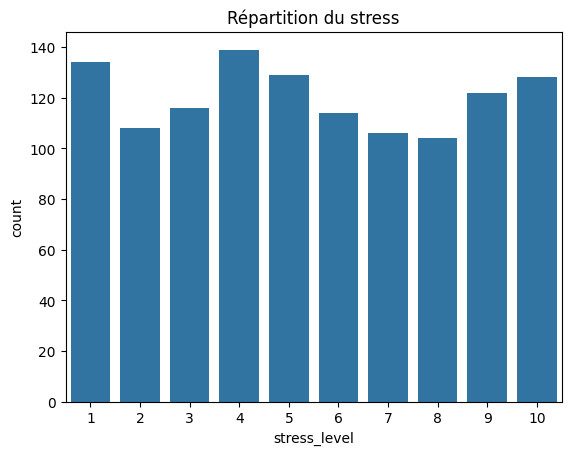

In [17]:
sns.countplot(x="stress_level", data=df)
plt.title("Répartition du stress")
plt.show()

## 4. Analyse bivariée

Cette partie cherche à étudier les relations entre plusieurs variables afin d’identifier des associations possibles entre usage des réseaux sociaux, sommeil, genre, plateforme et niveau de stress.
### Interprétation

Ce boxplot permet de comparer le temps passé sur les réseaux sociaux selon le niveau de stress. Si les groupes ayant un stress plus élevé présentent aussi un temps d’écran plus important, cela peut suggérer une association entre exposition numérique et stress.


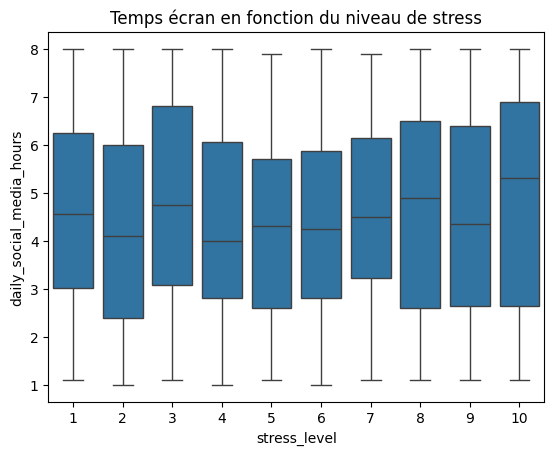

In [18]:
sns.boxplot(x="stress_level", y="daily_social_media_hours", data=df)
plt.title("Temps écran en fonction du niveau de stress")
plt.show()

### Interprétation

Ce nuage de points permet d’observer la relation entre le temps passé sur les réseaux sociaux et le nombre d’heures de sommeil. Une tendance décroissante pourrait indiquer qu’un usage plus important des réseaux sociaux est associé à une diminution du sommeil.


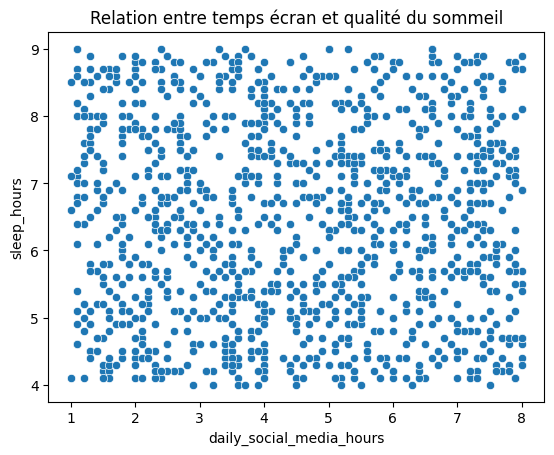

In [19]:
sns.scatterplot(x="daily_social_media_hours", y="sleep_hours", data=df)
plt.title("Relation entre temps écran et qualité du sommeil")
plt.show()

In [20]:
print(df.columns)

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='str')


### Interprétation

Cette visualisation compare la répartition du stress selon le genre. Elle permet de repérer d’éventuelles différences entre groupes et de voir si certains profils semblent davantage concernés par un niveau de stress élevé.


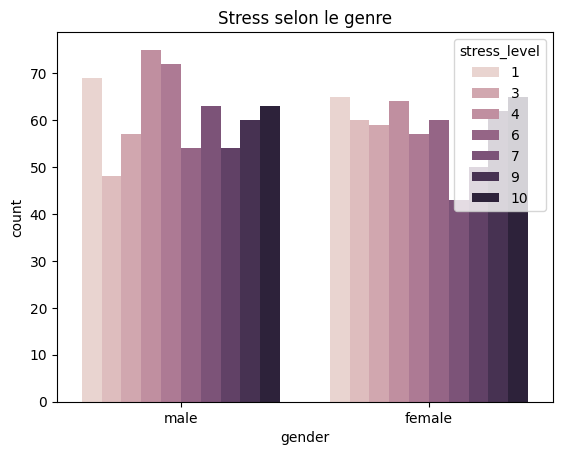

In [21]:
sns.countplot(x="gender", hue="stress_level", data=df)
plt.title("Stress selon le genre")
plt.show()

### Interprétation

Ce graphique permet d’examiner si certaines plateformes sont plus souvent associées à des niveaux de stress élevés. Il ne prouve pas une causalité, mais il peut mettre en évidence des tendances intéressantes pour l’analyse.


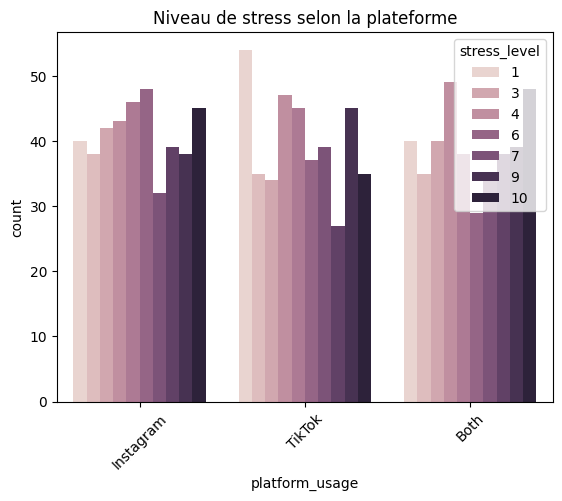

In [22]:
sns.countplot(x="platform_usage", hue="stress_level", data=df)
plt.title("Niveau de stress selon la plateforme")
plt.xticks(rotation=45)
plt.show()

## 5. Analyse des corrélations

La matrice de corrélation permet de mesurer l’intensité des relations linéaires entre les variables numériques du dataset.
### Interprétation

La matrice de corrélation permet d’identifier les variables les plus fortement associées entre elles. Les coefficients proches de 1 ou de -1 signalent une relation plus forte, tandis que les coefficients proches de 0 indiquent une faible relation linéaire.

Il est important de rappeler qu’une corrélation ne signifie pas nécessairement une causalité.


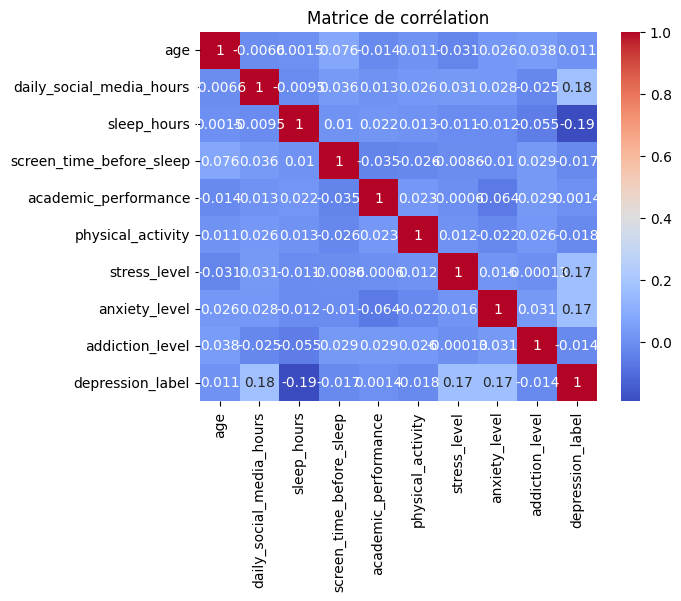

In [23]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

## 6. KPI retenus pour le dashboard

À partir de cette analyse exploratoire, les indicateurs les plus pertinents à mettre en avant dans le dashboard sont :

- le nombre total d’adolescents dans l’échantillon,
- l’âge moyen,
- le temps moyen passé sur les réseaux sociaux,
- le temps moyen de sommeil,
- le niveau moyen de stress,
- la relation entre temps d’écran et sommeil,
- la relation entre temps d’écran et stress.
## 7. Conclusion générale

L’analyse exploratoire met en évidence plusieurs relations possibles entre l’usage des réseaux sociaux, le sommeil et le niveau de stress des adolescents. Les graphiques montrent que certaines variables, comme le temps passé sur les réseaux sociaux et le sommeil, semblent particulièrement importantes pour comprendre les profils les plus exposés au stress.

Ces résultats justifient la construction d’un dashboard interactif permettant d’explorer ces relations de manière plus claire et plus dynamique.
## 8. Recommandations

À partir de cette analyse, plusieurs pistes peuvent être envisagées :

- surveiller le temps quotidien passé sur les réseaux sociaux,
- sensibiliser les adolescents à l’importance du sommeil,
- identifier les profils les plus à risque selon leurs habitudes numériques,
- utiliser le dashboard comme outil de visualisation et d’aide à l’interprétation.
## 9. Limites de l’étude

Cette analyse repose sur un dataset observé et non sur une expérimentation contrôlée. Par conséquent :

- les relations observées sont des associations et non des preuves de causalité,
- certaines variables peuvent être influencées par d’autres facteurs non présents dans le dataset,
- les résultats doivent être interprétés avec prudence.


In [24]:
!jupyter nbconvert --to script analysis.ipynb --output dashboard

usage: python.exe c:\Users\LOQ\AppData\Roaming\Python\Python314\Scripts\jupyter
       [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir] [--paths]
       [--json] [--debug]
       [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: kernel kernelspec migrate run troubleshoot

Jupyter command `jupyter-nbconvert` not found.
